# Arrhenius

In [1]:
# --------------------------------------------------------
# External packages
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tabulate import tabulate

# --------------------------------------------------------
# KiRATE modules
from KiRATE.kinetics import Arrhenius, ReparametrizedArrhenius

This tutorial demonstrates how to compute kinetic rate constants for a simple Arrhenius reaction over a specified temperature range. The implementation focuses exclusively on the forward reaction rate constant, as defined by user-provided parameters. Chemical equilibrium is not considered; therefore, the reaction is treated as strictly unidirectional.

- Equation
    > $k_f(T) = A \: T^n \: exp\left(-\frac{Eact}{RT}\right)$
- CHEMKIN
    >```
    >H2 + O = H + OH    +5.080E+04 +2.670E+00 +6.292E+03
    >```
- The rate constant can be represented as a Python object by directly passing a dictionary of parameters to the `Arrhenius` constructor. The reaction name is optional and may be omitted. Internally, the library performs consistency checks to ensure the physical validity of the provided parameters.
  
  **From dictionary**
    >```python
    >reaction = Arrhenius(
    >    name="H2+O=H+OH",
    >    parameters={"A": 5.080e+04, "n": 2.670E+00, "Ea": 6.292e+03}
    >)
    >```

  **From CHEMKIN string**
    >```python
    >reaction = Arrhenius.from_chemkin("H2+O=H+OH  5.080e+04 2.670E+00 6.292e+03")
    >```

In [2]:
# --------------------------------------------------------
# Construction from a python dictionary
reaction = Arrhenius(name="H2+O=H+OH", parameters={"A": 5.080e+04, "n": 2.670E+00, "Ea": 6.292e+03})

# --------------------------------------------------------
# Construction from a CHEMKIN-fromatted string
reaction = Arrhenius.from_chemkin("H2+O=H+OH  5.080e+04 2.670E+00 6.292e+03")

# --------------------------------------------------------
# Object inspection
print(f"Representer:\n{repr(reaction)}\n")
print(f"String representation:\n{str(reaction)}") # This always print the CHEMKIN-formatted string

Representer:
Arrhenius(
 name = H2+O=H+OH
 A    = 5.08000e+04
 n    = 2.67000e+00
 Ea   = 6.29200e+03
)

String representation:
H2+O=H+OH		5.08000E+04 2.67000E+00 6.29200E+03


## Rate constant computation

Once the rate constant is properly initialized, the Arrhenius object exposes its dedicated methods, including routines for evaluating the kinetic constant over a range of temperatures. Note that both the standard and modified Arrhenius formulations define the kinetic constant solely as a function of temperature.

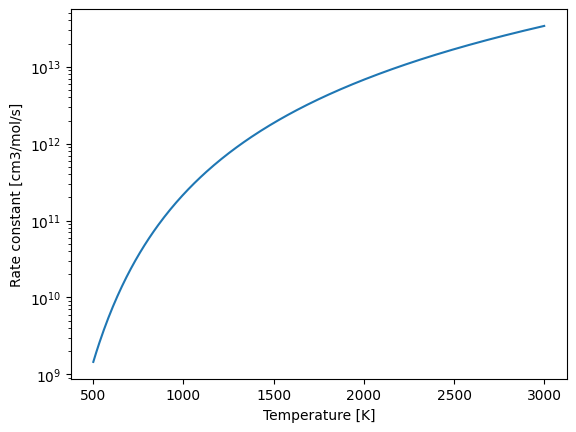

In [3]:
# --------------------------------------------------------
# Compute the rate constant
T_range = jnp.linspace(500, 3000, 300)
kinetic_constant = reaction.rate_constant(T_range)

# --------------------------------------------------------
# Let's visualize it
plt.semilogy(T_range, kinetic_constant)
plt.xlabel("Temperature [K]")
plt.ylabel("Rate constant [cm3/mol/s]")
plt.show()